## Import

In [100]:
import ztpcraft as ztpc
import numpy as np
import matplotlib.pyplot as plt

# two-loop fluxoid jump model
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxoid_model import (
    FluxoidModelParams,
    FluxoidSector,
)
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxoid_system import (
    TwoLoopFluxoidSystem,
)
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxoid_transition_rates import (
    build_global_states,
)
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxoid_transition_rates import (
    SectorJumpOperator,
)
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxoid_transition_rates import (
    compute_all_decay_rates,
    sector_rate_matrix,
    sector_to_sector_rate,
)
from ztpcraft.decoherence import QuantumNoiseSpectralDensity
import tqdm

## Parameter

In [157]:
base_param_set = FluxoidModelParams(
    EL_a=0.46307,
    EL_b=0.43693,
    EJ=5.1,
    EC=0.812,
    phi_ext_a=np.pi,
    phi_ext_b=-np.pi,
    flux_allocation_alpha=0.0,  # 0 --> allocate to JJ, 1 --> allocate to the inductive term
)

fluxoid_numbers_of_interest = [(i, 0) for i in range(-8, 9)]
sector_dict = {
    fluxoid_numbers: FluxoidSector(*fluxoid_numbers)
    for fluxoid_numbers in fluxoid_numbers_of_interest
}

system = TwoLoopFluxoidSystem(base_param_set, evals_count=15, cutoff=50)
states = build_global_states(list(sector_dict.values()), system)

## Calculation

#### Jump operators

In [158]:
raise_a = SectorJumpOperator(system, (1, 0))
lower_a = SectorJumpOperator(system, (-1, 0))

raise_b = SectorJumpOperator(system, (0, 1))
lower_b = SectorJumpOperator(system, (0, -1))

In [159]:
m_x_a = raise_a + lower_a
m_x_b = raise_b + lower_b
swap_ab = raise_a * lower_b + (raise_a * lower_b).dagger()

#### Spectral density

In [160]:
T = 0.5
noise = QuantumNoiseSpectralDensity(
    alpha=1E-80,
    s=1.0,                     # Ohmic
    temperature=T,             # bath temperature used in Bose factor
    cutoff_type="exponential", # or "hard", or None
    cutoff_freq=2*np.pi*20e9,  # rad/s (here: 20 GHz * 2pi)
)

#### Study 1: fix temperature $T = 20$ mK, $\Phi_{\text{diff}} = 1 \Phi_0$, sweep $\Phi_{\text{cm}}$, flux allocated to the JJ term

In [161]:
from dataclasses import dataclass
from typing import Any


@dataclass
class FluxSweepPoint:
    """One common-mode flux point: parameters, system, states, and rate outputs."""

    phi_cm: float
    params: FluxoidModelParams
    system: TwoLoopFluxoidSystem
    states: list
    rates_ij: dict[tuple[int, int], float]
    gamma_mat: Any

In [195]:
T = 0.2
sectors = list(sector_dict.values())

phi_cm_list = np.linspace(0, 2, 101) * 2 * np.pi
sweep_results: list[FluxSweepPoint] = []

for phi_cm in tqdm.tqdm(phi_cm_list):
    phi_ext_a = base_param_set.phi_ext_a + phi_cm / 2
    phi_ext_b = base_param_set.phi_ext_b + phi_cm / 2
    params = FluxoidModelParams(
        EL_a=base_param_set.EL_a,
        EL_b=base_param_set.EL_b,
        EJ=base_param_set.EJ,
        EC=base_param_set.EC,
        phi_ext_a=phi_ext_a,
        phi_ext_b=phi_ext_b,
        flux_allocation_alpha=base_param_set.flux_allocation_alpha,
    )
    system = TwoLoopFluxoidSystem(params, cutoff=60, evals_count=15)
    states = build_global_states(sectors, system)
    raise_a = SectorJumpOperator(system=system, delta=(1, 0))
    lower_a = SectorJumpOperator(system=system, delta=(-1, 0))
    O_a = raise_a + lower_a
    rates_ij = compute_all_decay_rates(
        system=system,
        states=states,
        operator=O_a,
        spectral_density=noise.S,
        T=T,
    )
    gamma_mat = sector_rate_matrix(
        system=system,
        sectors=sectors,
        states=states,
        operator=O_a,
        spectral_density=noise.S,
        T=T,
    )
    sweep_results.append(
        FluxSweepPoint(
            phi_cm=phi_cm,
            params=params,
            system=system,
            states=states,
            rates_ij=rates_ij,
            gamma_mat=gamma_mat,
        )
    )

all_pairwise_by_flux = [p.rates_ij for p in sweep_results]
sector_matrix_by_flux = [p.gamma_mat for p in sweep_results]

100%|██████████| 101/101 [05:14<00:00,  3.12s/it]


### Post-process: lowest-energy near-integer vs near-half flux sectors

For each `sweep_results` entry, pick the sector with **lowest ground-state energy** among those with `mod(φ_eff/(2π), 1)` near `0` (**near-zero**) and similarly near `0.5` (**near-half**). Then read thermally weighted sector rates from `gamma_mat` and bare GS→GS rates from `rates_ij`.

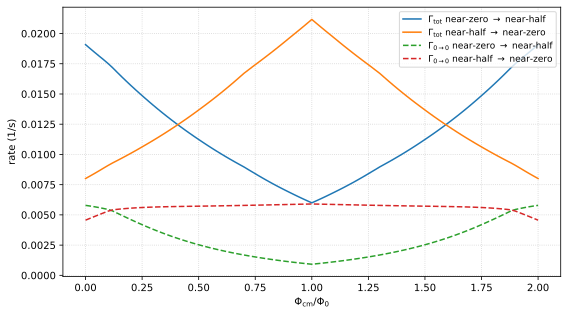

In [202]:
from dataclasses import dataclass


def fractional_flux_quantum(phi_eff: float) -> float:
    """Fractional part of effective flux in units of one flux quantum (2π rad)."""
    return float(np.mod(phi_eff / (2.0 * np.pi), 1.0))


def is_near_zero_flux(phi_eff: float, tol: float = 0.2) -> bool:
    f = fractional_flux_quantum(phi_eff)
    return min(f, 1.0 - f) < tol


def is_near_half_flux(phi_eff: float, tol: float = 0.2) -> bool:
    f = fractional_flux_quantum(phi_eff)
    return abs(f - 0.5) < tol


def ground_state_energy(system: TwoLoopFluxoidSystem, sector: FluxoidSector) -> float:
    return float(system.eigenvalues_with_offset(sector)[0])


def pick_lowest_energy_sector(
    candidates: list[FluxoidSector], system: TwoLoopFluxoidSystem
) -> FluxoidSector | None:
    if not candidates:
        return None
    return min(candidates, key=lambda s: ground_state_energy(system, s))


def global_index_ground_state(states, sector: FluxoidSector) -> int | None:
    for i, st in enumerate(states):
        if st.sector == sector and st.level == 0:
            return i
    return None


@dataclass
class NearZeroHalfRates:
    phi_cm: float
    sector_near_zero: FluxoidSector | None
    sector_near_half: FluxoidSector | None
    # Thermally weighted totals (same definition as sector_rate_matrix)
    gamma_tot_near_zero_to_near_half: float
    gamma_tot_near_half_to_near_zero: float
    # Microscopic FGR rates for GS -> GS only
    gamma_gs_near_zero_to_near_half: float
    gamma_gs_near_half_to_near_zero: float


def postprocess_near_zero_half_sectors(
    sweep_results: list[FluxSweepPoint],
    sectors: list[FluxoidSector],
    flux_tol: float = 0.2,
) -> list[NearZeroHalfRates]:
    rows: list[NearZeroHalfRates] = []
    for p in sweep_results:
        model = p.system.model
        near_zero: list[FluxoidSector] = []
        near_half: list[FluxoidSector] = []
        for s in sectors:
            phi_eff = model.effective_flux(s)
            if is_near_zero_flux(phi_eff, flux_tol):
                near_zero.append(s)
            if is_near_half_flux(phi_eff, flux_tol):
                near_half.append(s)

        s0 = pick_lowest_energy_sector(near_zero, p.system)
        s1 = pick_lowest_energy_sector(near_half, p.system)

        if s0 is None or s1 is None:
            rows.append(
                NearZeroHalfRates(
                    phi_cm=p.phi_cm,
                    sector_near_zero=s0,
                    sector_near_half=s1,
                    gamma_tot_near_zero_to_near_half=float("nan"),
                    gamma_tot_near_half_to_near_zero=float("nan"),
                    gamma_gs_near_zero_to_near_half=float("nan"),
                    gamma_gs_near_half_to_near_zero=float("nan"),
                )
            )
            continue

        i0 = sectors.index(s0)
        i1 = sectors.index(s1)
        gmat = p.gamma_mat

        i_gs_0 = global_index_ground_state(p.states, s0)
        i_gs_1 = global_index_ground_state(p.states, s1)
        r = p.rates_ij

        rows.append(
            NearZeroHalfRates(
                phi_cm=p.phi_cm,
                sector_near_zero=s0,
                sector_near_half=s1,
                gamma_tot_near_zero_to_near_half=float(gmat[i0, i1]),
                gamma_tot_near_half_to_near_zero=float(gmat[i1, i0]),
                gamma_gs_near_zero_to_near_half=float(r.get((i_gs_0, i_gs_1), 0.0))
                if i_gs_0 is not None and i_gs_1 is not None
                else float("nan"),
                gamma_gs_near_half_to_near_zero=float(r.get((i_gs_1, i_gs_0), 0.0))
                if i_gs_0 is not None and i_gs_1 is not None
                else float("nan"),
            )
        )
    return rows


post_rows = postprocess_near_zero_half_sectors(sweep_results, sectors, flux_tol=0.15)

phi_cm_arr = np.array([r.phi_cm for r in post_rows])
x_flux0 = phi_cm_arr / (2.0 * np.pi)

y_tot_0h = np.array([r.gamma_tot_near_zero_to_near_half for r in post_rows])
y_tot_h0 = np.array([r.gamma_tot_near_half_to_near_zero for r in post_rows])
y_gs_0h = np.array([r.gamma_gs_near_zero_to_near_half for r in post_rows])
y_gs_h0 = np.array([r.gamma_gs_near_half_to_near_zero for r in post_rows])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_flux0, y_tot_0h, label=r"$\Gamma_{\mathrm{tot}}$ near-zero $\to$ near-half")
ax.plot(x_flux0, y_tot_h0, label=r"$\Gamma_{\mathrm{tot}}$ near-half $\to$ near-zero")
ax.plot(x_flux0, y_gs_0h, "--", label=r"$\Gamma_{0\to0}$ near-zero $\to$ near-half")
ax.plot(x_flux0, y_gs_h0, "--", label=r"$\Gamma_{0\to0}$ near-half $\to$ near-zero")
ax.set_xlabel(r"$\Phi_{\mathrm{cm}} / \Phi_0$")
ax.set_ylabel("rate (1/s)")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.6)
plt.tight_layout()

In [181]:
post_rows[-1].sector_near_zero

FluxoidSector(m_a=-1, m_b=0)

In [182]:
post_rows[0].sector_near_zero

FluxoidSector(m_a=1, m_b=0)

In [184]:
sweep_results[0].system.model.effective_flux(post_rows[0].sector_near_zero)/2/np.pi

-1.0145222222222223

In [ ]:
idx = -1
for sector in sectors:
    print(
        sector,
        sweep_results[idx].system.model.effective_flux(sector) / 2 / np.pi,
        sweep_results[idx].system.model.energy_offset(sector),
    )

FluxoidSector(m_a=-8, m_b=0) 3.601655555555556 217.44119318833603
FluxoidSector(m_a=-7, m_b=0) 3.087133333333333 159.75271336285917
FluxoidSector(m_a=-6, m_b=0) 2.5726111111111107 110.9393842797633
FluxoidSector(m_a=-5, m_b=0) 2.058088888888889 71.0012059390485
FluxoidSector(m_a=-4, m_b=0) 1.5435666666666665 39.93817834071479
FluxoidSector(m_a=-3, m_b=0) 1.0290444444444444 17.750301484762126
FluxoidSector(m_a=-2, m_b=0) 0.5145222222222222 4.4375753711905315
FluxoidSector(m_a=-1, m_b=0) 0.0 0.0
FluxoidSector(m_a=0, m_b=0) -0.5145222222222222 4.4375753711905315
FluxoidSector(m_a=1, m_b=0) -1.0290444444444444 17.750301484762126
FluxoidSector(m_a=2, m_b=0) -1.5435666666666665 39.93817834071479
FluxoidSector(m_a=3, m_b=0) -2.058088888888889 71.0012059390485
FluxoidSector(m_a=4, m_b=0) -2.5726111111111107 110.9393842797633
FluxoidSector(m_a=5, m_b=0) -3.087133333333333 159.75271336285917
FluxoidSector(m_a=6, m_b=0) -3.601655555555556 217.44119318833603
FluxoidSector(m_a=7, m_b=0) -4.11617777

In [189]:
idx = 0
for sector in sectors:
    print(
        sector,
        sweep_results[idx].system.model.effective_flux(sector) / 2 / np.pi,
        sweep_results[idx].system.model.energy_offset(sector),
    )

FluxoidSector(m_a=-8, m_b=0) 3.6161777777777773 284.00482375619384
FluxoidSector(m_a=-7, m_b=0) 3.101655555555556 217.4411931883361
FluxoidSector(m_a=-6, m_b=0) 2.5871333333333326 159.75271336285917
FluxoidSector(m_a=-5, m_b=0) 2.072611111111111 110.93938427976329
FluxoidSector(m_a=-4, m_b=0) 1.558088888888889 71.0012059390485
FluxoidSector(m_a=-3, m_b=0) 1.0435666666666665 39.93817834071479
FluxoidSector(m_a=-2, m_b=0) 0.5290444444444443 17.75030148476213
FluxoidSector(m_a=-1, m_b=0) 0.014522222222222181 4.4375753711905315
FluxoidSector(m_a=0, m_b=0) -0.5 0.0
FluxoidSector(m_a=1, m_b=0) -1.0145222222222223 4.4375753711905315
FluxoidSector(m_a=2, m_b=0) -1.5290444444444442 17.750301484762144
FluxoidSector(m_a=3, m_b=0) -2.0435666666666665 39.93817834071479
FluxoidSector(m_a=4, m_b=0) -2.558088888888889 71.0012059390485
FluxoidSector(m_a=5, m_b=0) -3.0726111111111107 110.9393842797633
FluxoidSector(m_a=6, m_b=0) -3.587133333333334 159.75271336285914
FluxoidSector(m_a=7, m_b=0) -4.101655

In [176]:
flux_points_near_half = np.array([sweep_results[idx].system.model.effective_flux(post_rows[idx].sector_near_half)/2/np.pi for idx in range(len(post_rows))])
flux_points_near_zero = np.array([sweep_results[idx].system.model.effective_flux(post_rows[idx].sector_near_zero)/2/np.pi for idx in range(len(post_rows))])


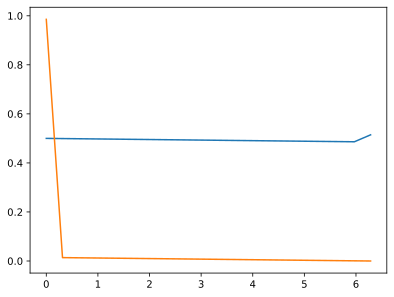

In [180]:
plt.plot(phi_cm_list, np.mod(flux_points_near_half, 1))
plt.plot(phi_cm_list, np.mod(flux_points_near_zero, 1))

In [1]:
import scqubits as scq

In [3]:
flxn = scq.Fluxonium(
    EJ=5.1,
    EC=0.812,
    EL=0.46307,
    flux=0.5,
    cutoff=50
)

In [6]:
evals, evecs = flxn.eigensys()

In [7]:
flxn.n_operator(energy_esys=(evals, evecs))

array([[0.-1.37424641e-31j, 0.+2.73153423e-02j, 0.-2.82330821e-15j,
        0.-5.90193619e-01j, 0.+3.11161141e-16j, 0.+2.83387534e-02j],
       [0.-2.73153423e-02j, 0.-2.01448027e-32j, 0.+6.02455105e-01j,
        0.-2.43127778e-15j, 0.-2.13496518e-01j, 0.+3.25826677e-16j],
       [0.+2.82330821e-15j, 0.-6.02455105e-01j, 0.-8.36337776e-32j,
        0.-3.25813506e-01j, 0.+1.02006553e-15j, 0.+5.00356021e-01j],
       [0.+5.90193619e-01j, 0.+2.43127778e-15j, 0.+3.25813506e-01j,
        0.+4.58689811e-32j, 0.+8.48503673e-01j, 0.-1.93078989e-16j],
       [0.-3.11161141e-16j, 0.+2.13496518e-01j, 0.-1.02006553e-15j,
        0.-8.48503673e-01j, 0.+1.38266171e-32j, 0.-8.49024321e-01j],
       [0.-2.83387534e-02j, 0.-3.25826677e-16j, 0.-5.00356021e-01j,
        0.+1.93078989e-16j, 0.+8.49024321e-01j, 0.+4.74840328e-32j]])